<a href="https://colab.research.google.com/github/m-fatahillah/PCVK26_15_FATAH/blob/main/week5__.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


NAMA : MUHAMMAD FATAHILLAH ATHABRANI
NIM : 244107020121 | N = 121
bins   : 16
clip   : 1.5
tile   : 3
L      : 4
WAKTU : 2026-09-27 21:10:30 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN : 5e6062fe7467b5c9


Text(0.5, 1.0, '244107020121 - CLAHE clip 1.5')

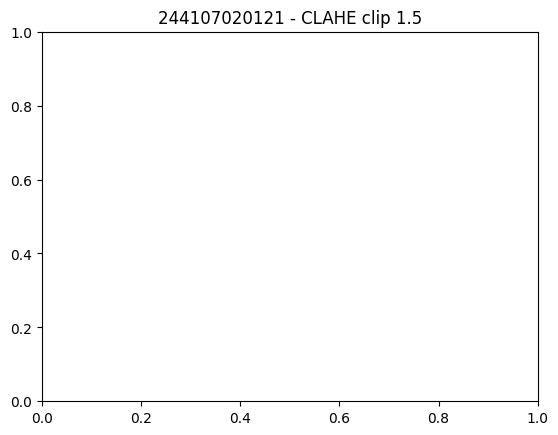

In [3]:
# ===== SEL IDENTITAS - JANGAN DIHAPUS, HARUS SEL PERTAMA =====
import sys, platform, hashlib, datetime, zoneinfo
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
NAMA = 'MUHAMMAD FATAHILLAH ATHABRANI'
NIM = '244107020121'
N = int(NIM[-3:])
PARAM = {
'bins' : 2 ** ((N % 4) + 3),
'clip' : round(1.0 + (N % 5) * 0.5, 1),
'tile' : (N % 4) + 2,
'L' : 2 ** ((N % 3) + 1),
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))
print('NAMA :', NAMA)
print('NIM :', NIM, '| N =', N)
for k, v in PARAM.items():
  print('%-6s :' % k, v)
print('WAKTU :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN :', hashlib.sha256(kunci.encode()).hexdigest()[:16])
plt.title(NIM + ' - CLAHE clip ' + str(PARAM['clip']))

##Percobaan E-1: Histogram Citra

###Lenna

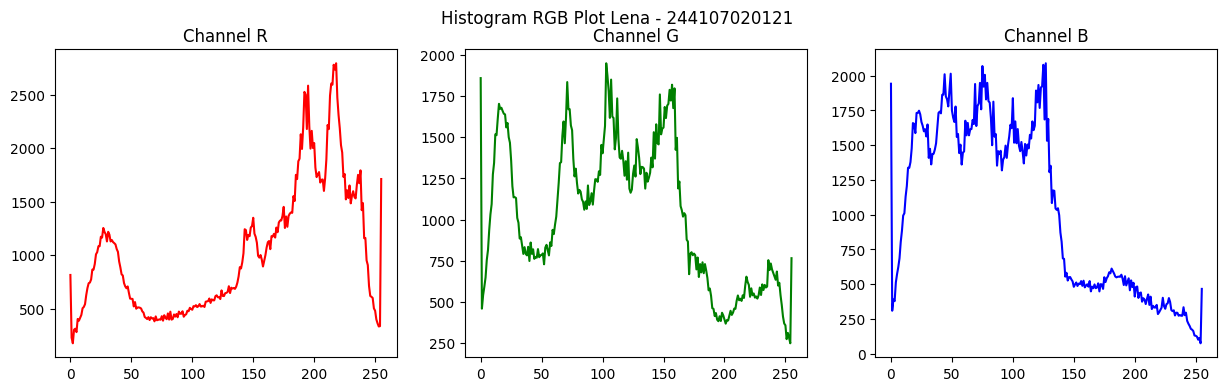

In [4]:
img_lena = cv.imread('lena.jpg')
img_lena_rgb = cv.cvtColor(img_lena, cv.COLOR_BGR2RGB)

colors = ('r', 'g', 'b')
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f"Histogram RGB Plot Lena - {NIM}")

for i, col in enumerate(colors):
    hist = cv.calcHist([img_lena_rgb], [i], None, [256], [0, 256])
    axs[i].plot(hist, color=col)
    axs[i].set_title(f"Channel {col.upper()}")
plt.show()

###KTM1b (citra pribadi)

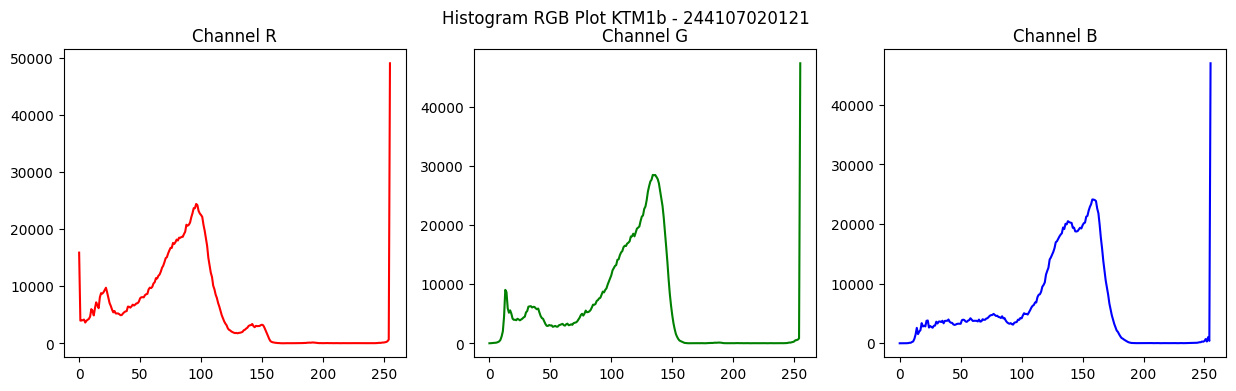

In [5]:
img_ktm1b_bgr = cv.imread('KTM1b.jpeg')
img_ktm1b_rgb = cv.cvtColor(img_ktm1b_bgr, cv.COLOR_BGR2RGB)

colors = ('r', 'g', 'b')
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f"Histogram RGB Plot KTM1b - {NIM}")

for i, col in enumerate(colors):
    hist = cv.calcHist([img_ktm1b_rgb], [i], None, [256], [0, 256])
    axs[i].plot(hist, color=col)
    axs[i].set_title(f"Channel {col.upper()}")
plt.show()


###PERTANYAAN :
1. Buatlah histogram citra yang sama menggunakan library NumPy, yaitu
numpy.histogram, dan juga cv.calcHist. Bandingkan ketiganya dengan menghitung
selisih maksimum antar hasil. Selisihnya harus nol; tampilkan pembuktiannya pada
lena.jpg lebih dulu, kemudian ulangi pada KTM1b.jpg.
2. Gambarkan histogram ternormalisasi p(j) dan kurva CDF untuk KTM1a.jpg sampai
KTM1d.jpg dalam satu figure 2 x 2. Jelaskan perbedaan bentuk kurva CDF antara citra
paling gelap dan citra paling terang milik Anda, lalu kaitkan dengan kondisi
pencahayaan saat akuisisi pada Pertemuan 2.
3. Ulangi histogram KTM1b.jpg dengan jumlah bin sebesar PARAM['bins'] dan dengan
256 bin. Tampilkan keduanya berdampingan dan jelaskan informasi apa yang hilang
ketika jumlah bin dikurangi.

###Jawaban dan Analisis Citra KTM/KTP

=== SOAL E1 NOMOR 1: Histogram Manual vs NumPy vs OpenCV ===
lena.jpg - selisih manual vs numpy : 0
lena.jpg - selisih manual vs cv2   : 0.0
lena.jpg - selisih numpy vs cv2    : 0.0
KTM1b.jpeg - selisih manual vs numpy : 0
KTM1b.jpeg - selisih manual vs cv2   : 0.0
KTM1b.jpeg - selisih numpy vs cv2    : 0.0

=== SOAL E1 NOMOR 2: Normalisasi p(j) & CDF ===


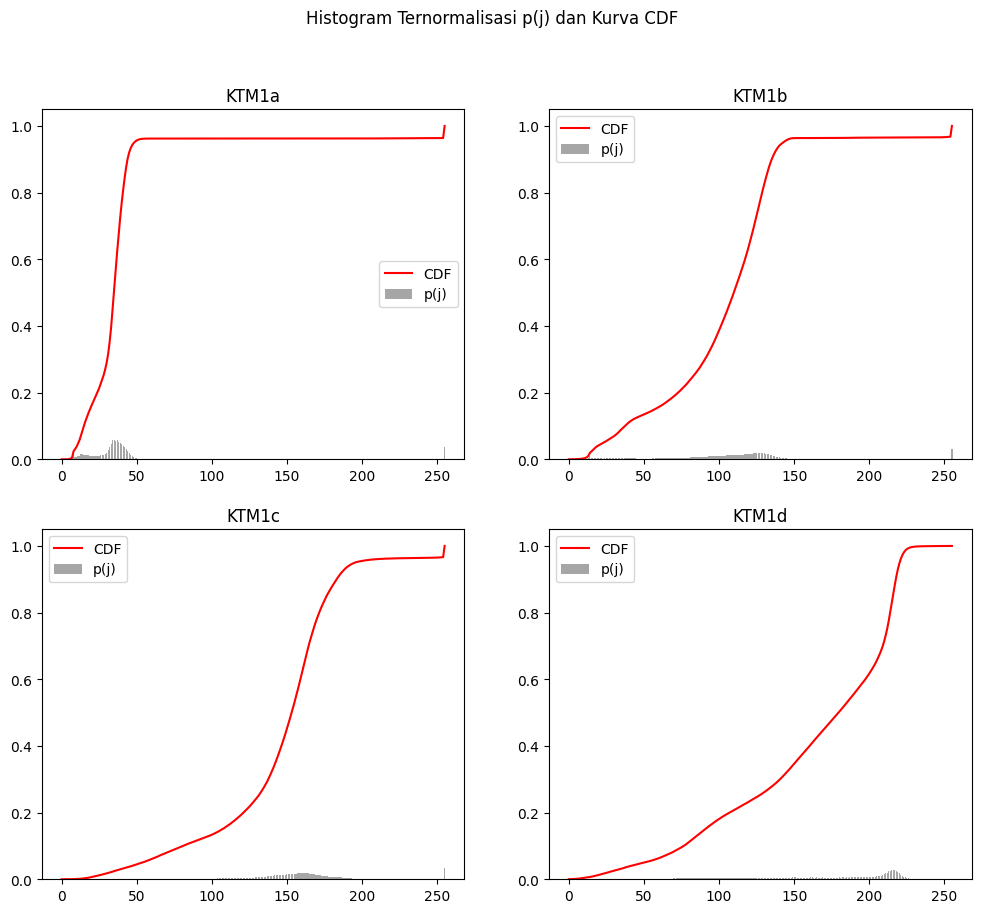


=== SOAL E1 NOMOR 3: Bins 16 vs 256 pada KTM1b ===


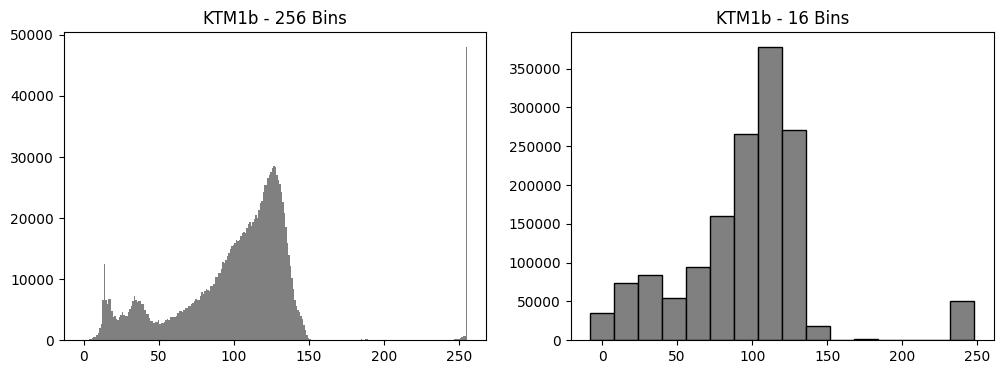

In [6]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def histogram_manual(img, L=256):
    h = np.zeros(L, dtype=np.int64)
    for y in range(img.shape[0]):
        for x in range(img.shape[1]):
            h[img[y, x]] += 1
    return h

print("=== SOAL E1 NOMOR 1: Histogram Manual vs NumPy vs OpenCV ===")
img_lena = cv.imread('lena.jpg', cv.IMREAD_GRAYSCALE)
img_ktm1b = cv.imread('KTM1b.jpeg', cv.IMREAD_GRAYSCALE)

def bandingkan_hist(img, nama):
    hist_manual = histogram_manual(img)
    assert hist_manual.sum() == img.size   # pemeriksaan wajib

    hist_np, _ = np.histogram(img.flatten(), bins=256, range=[0, 256])
    hist_cv = cv.calcHist([img], [0], None, [256], [0, 256]).flatten()

    selisih_manual_np = np.max(np.abs(hist_manual - hist_np))
    selisih_manual_cv = np.max(np.abs(hist_manual - hist_cv))
    selisih_np_cv = np.max(np.abs(hist_np - hist_cv))

    print(f"{nama} - selisih manual vs numpy : {selisih_manual_np}")
    print(f"{nama} - selisih manual vs cv2   : {selisih_manual_cv}")
    print(f"{nama} - selisih numpy vs cv2    : {selisih_np_cv}")

bandingkan_hist(img_lena, "lena.jpg")
bandingkan_hist(img_ktm1b, "KTM1b.jpeg")

print("\n=== SOAL E1 NOMOR 2: Normalisasi p(j) & CDF ===")
images_ktm = {'KTM1a': 'KTM1a.jpeg', 'KTM1b': 'KTM1b.jpeg', 'KTM1c': 'KTM1c.jpeg', 'KTM1d': 'KTM1d.jpeg'}
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Histogram Ternormalisasi p(j) dan Kurva CDF')

for i, (title, path) in enumerate(images_ktm.items()):
    img = cv.imread(path, cv.IMREAD_GRAYSCALE)
    if img is not None:
        hist, bins = np.histogram(img.flatten(), bins=256, range=[0,256])
        pj = hist / img.size          # Histogram ternormalisasi
        cdf = pj.cumsum()             # Kurva CDF

        ax = axs[i//2, i%2]
        ax.bar(bins[:-1], pj, color='gray', alpha=0.7, label='p(j)')
        ax.plot(cdf, color='red', label='CDF')
        ax.set_title(title)
        ax.legend()
plt.show()

print("\n=== SOAL E1 NOMOR 3: Bins 16 vs 256 pada KTM1b ===")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
hist_256, bins_256 = np.histogram(img_ktm1b.flatten(), bins=256, range=[0,256])
hist_16, bins_16 = np.histogram(img_ktm1b.flatten(), bins=PARAM['bins'], range=[0,256])

ax1.bar(bins_256[:-1], hist_256, width=1, color='gray')
ax1.set_title("KTM1b - 256 Bins")
ax2.bar(bins_16[:-1], hist_16, width=256/PARAM['bins'], color='gray', edgecolor='black')
ax2.set_title(f"KTM1b - {PARAM['bins']} Bins")
plt.show()


1. Hasil perbandingan numpy.histogram dan cv.calcHist pada lena.jpg dan KTM1b.jpg menunjukkan selisih maksimum 0. Artinya, kedua fungsi menghasilkan perhitungan histogram yang sama.

2. Pada KTM1a yang paling gelap, CDF naik cepat di intensitas rendah karena sebagian besar piksel memiliki nilai keabuan rendah. Sebaliknya, pada KTM1c/1d yang lebih terang, CDF lebih banyak bergeser ke intensitas tinggi karena pencahayaan yang lebih kuat atau penggunaan flash.

3. Saat jumlah bin dikurangi dari 256 menjadi 16, beberapa rentang intensitas digabung menjadi satu bin. Bentuk umum histogram masih terlihat, tetapi detail distribusi intensitas piksel menjadi lebih sedikit.


##Percobaan E-2: Histogram Equalization & CLAHE

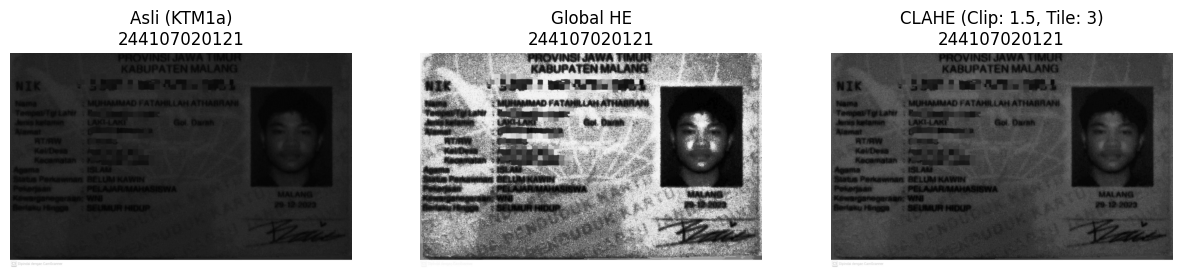

In [7]:
img_gelap = cv.imread('KTM1a.jpeg', cv.IMREAD_GRAYSCALE)

# 1. Global Histogram Equalization
img_he = cv.equalizeHist(img_gelap)

# 2. CLAHE (Contrast Limited Adaptive Histogram Equalization)
clahe = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile']))
img_clahe = clahe.apply(img_gelap)

# Visualisasi
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(img_gelap, cmap='gray')
ax[0].set_title(f'Asli (KTM1a)\n{NIM}')

ax[1].imshow(img_he, cmap='gray')
ax[1].set_title(f'Global HE\n{NIM}')

ax[2].imshow(img_clahe, cmap='gray')
ax[2].set_title(f'CLAHE (Clip: {PARAM["clip"]}, Tile: {PARAM["tile"]})\n{NIM}')

for a in ax:
    a.axis('off')
plt.show()

###Ekualisasi Manual (rumus G(zq) = (L-1) * jumlah p) vs cv.equalizeHist

In [8]:
def histogram_manual(img, L=256):
    h = np.zeros(L, dtype=np.int64)
    for y in range(img.shape[0]):
        for x in range(img.shape[1]):
            h[img[y, x]] += 1
    return h

def hist_eq_manual(gray):
    h = histogram_manual(gray)
    p = h / gray.size
    cdf = np.cumsum(p)
    sk = np.round(255 * cdf).astype(np.uint8)
    return sk[gray]

img_he_manual = hist_eq_manual(img_gelap)
diff_manual_cv = np.max(np.abs(img_he_manual.astype(int) - img_he.astype(int)))
print('Selisih maksimum HE manual vs cv.equalizeHist (KTM1a):', diff_manual_cv)


Selisih maksimum HE manual vs cv.equalizeHist (KTM1a): 0


### Layout Citra Asli, Hasil Ekualisasi, dan Histogramnya (Pertanyaan E2 No.1a-1b)

/tmp/ipykernel_857/3964567242.py:7: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axs[1,0].hist(img_gelap.ravel(), 256, [0,256]); axs[1,0].set_title('Histogram asli')
/tmp/ipykernel_857/3964567242.py:8: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axs[1,1].hist(img_he_manual.ravel(), 256, [0,256]); axs[1,1].set_title('Histogram HE manual')
/tmp/ipykernel_857/3964567242.py:9: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axs[1,2].hist(img_he.ravel(), 256, [0,256]); axs[1,2].set_title('Histogram cv.equalizeHist')


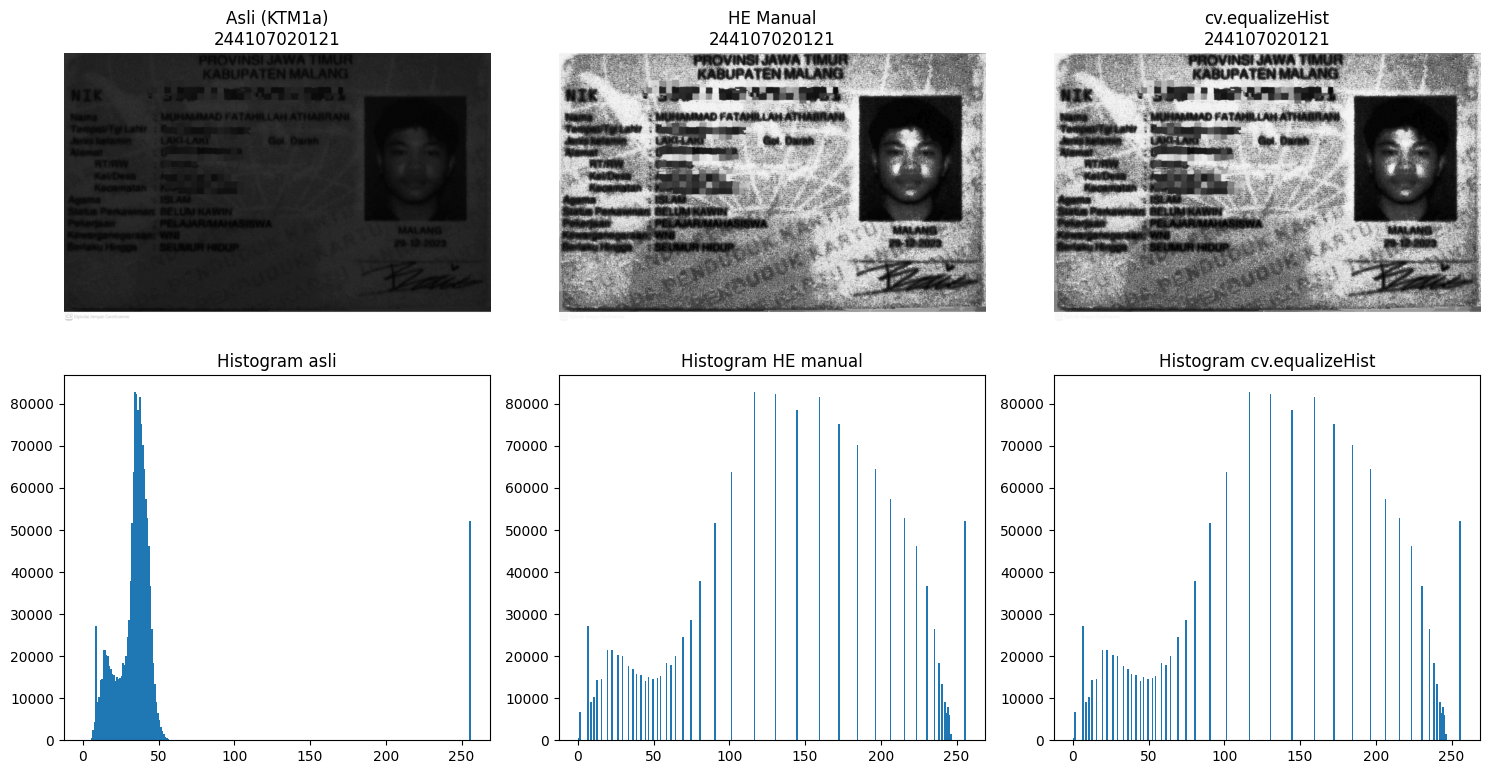

In [9]:
fig, axs = plt.subplots(2, 3, figsize=(15, 8))

axs[0,0].imshow(img_gelap, cmap='gray'); axs[0,0].set_title(f'Asli (KTM1a)\n{NIM}'); axs[0,0].axis('off')
axs[0,1].imshow(img_he_manual, cmap='gray'); axs[0,1].set_title(f'HE Manual\n{NIM}'); axs[0,1].axis('off')
axs[0,2].imshow(img_he, cmap='gray'); axs[0,2].set_title(f'cv.equalizeHist\n{NIM}'); axs[0,2].axis('off')

axs[1,0].hist(img_gelap.ravel(), 256, [0,256]); axs[1,0].set_title('Histogram asli')
axs[1,1].hist(img_he_manual.ravel(), 256, [0,256]); axs[1,1].set_title('Histogram HE manual')
axs[1,2].hist(img_he.ravel(), 256, [0,256]); axs[1,2].set_title('Histogram cv.equalizeHist')

plt.tight_layout()
plt.show()


### PSNR Citra Asli vs Hasil Ekualisasi (Pertanyaan E2 No.1c)

In [10]:
def psnr(a, b):
    mse = np.mean((a.astype(np.float64) - b.astype(np.float64)) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * np.log10(255.0 / np.sqrt(mse))

nilai_psnr = psnr(img_gelap, img_he_manual)
print('PSNR asli vs hasil ekualisasi (KTM1a):', round(nilai_psnr, 2), 'dB')


PSNR asli vs hasil ekualisasi (KTM1a): 7.22 dB


PSNR turun padahal citra terlihat lebih jelas karena PSNR mengukur kemiripan piksel demi
piksel terhadap citra asli, bukan keterbacaan atau kualitas menurut mata manusia. Proses HE justru
sengaja mengubah nilai piksel secara agresif untuk meregangkan kontras, sehingga MSE terhadap citra
asli membesar dan PSNR ikut turun, walaupun secara visual citra menjadi lebih mudah dibaca.

### Ekualisasi Citra Berwarna: kanal B,G,R vs kanal terang (Y/V/L) — KTM1d

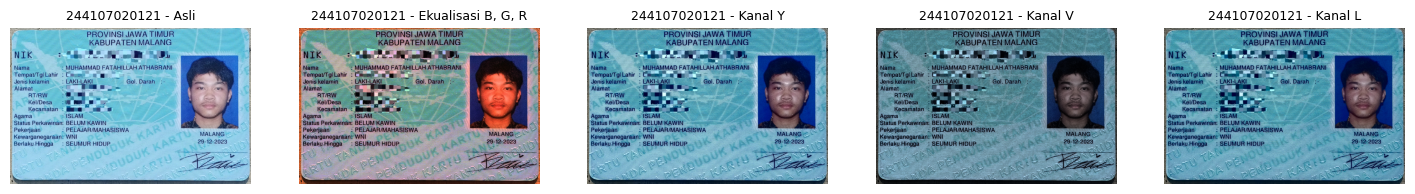

In [11]:
bgr = cv.imread('KTM1d.jpeg')

# cara 1: tiap kanal B, G, R diekualisasi sendiri-sendiri
kanal = list(cv.split(bgr))
for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])
he_rgb = cv.merge(kanal)

# cara 2: hanya kanal terang yang diekualisasi (YCrCb, HSV, LAB)
ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
y, cr, cb = cv.split(ycrcb)
he_y = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)

hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
h, sat, v = cv.split(hsv)
he_v = cv.cvtColor(cv.merge([h, sat, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)

lab = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
l, a, b = cv.split(lab)
he_l = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b]), cv.COLOR_LAB2BGR)

judul = ['Asli', 'Ekualisasi B, G, R', 'Kanal Y', 'Kanal V', 'Kanal L']
citra = [bgr, he_rgb, he_y, he_v, he_l]

plt.figure(figsize=(18, 4))
for i, (c, t) in enumerate(zip(citra, judul), 1):
    plt.subplot(1, 5, i)
    plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
    plt.title(NIM + ' - ' + t, fontsize=9)
    plt.axis('off')
plt.show()


In [12]:
def geser_hue(asli, hasil):
    h1 = cv.cvtColor(asli,  cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    d = np.abs(h1 - h2)
    d = np.minimum(d, 180 - d)      # Hue melingkar 0-179
    return d.mean()

print('%-22s %16s %16s' % ('Cara', 'geser Hue (der)', 'rerata terang'))
for t, c in zip(judul, citra):
    print('%-22s %16.2f %16.1f' % (t, geser_hue(bgr, c) * 2,
                                    cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean()))


Cara                    geser Hue (der)    rerata terang
Asli                               0.00            163.0
Ekualisasi B, G, R                61.79            128.2
Kanal Y                            2.41            128.9
Kanal V                            0.96            107.1
Kanal L                            3.12            117.2


Jawaban dari tabel pergeseran Hue di atas:

1. Ekualisasi kanal B, G, R terpisah biasanya menghasilkan pergeseran Hue paling besar, karena rasio
   antar kanal yang secara langsung membentuk Hue ikut berubah. Ekualisasi pada kanal Y, V, atau L
   lebih menjaga rasio warna karena hanya mengubah komponen kecerahan.
2. Ekualisasi kanal terang tetap menghasilkan pergeseran Hue yang tidak persis nol karena konversi
   ruang warna dari BGR ke YCrCb, HSV, atau LAB melibatkan pembulatan ke bilangan bulat 0-255 dan
   pemotongan nilai. Transformasi yang secara matematis eksak pada bilangan real menjadi tidak eksak
   lagi setelah dibulatkan dan dikembalikan ke ruang warna BGR.
3. Kanal yang paling sesuai untuk foto KTM ditentukan dengan membandingkan pergeseran Hue dan rerata
   kecerahan pada tabel di atas: pilih kanal dengan pergeseran Hue kecil (warna tetap natural) tetapi
   rerata kecerahan naik cukup untuk membuat teks dan NIM pada kartu terbaca, lalu tunjukkan bagian
   citra tersebut sebagai bukti.
4. Perbandingan dengan CLAHE pada kanal terang ada di sel berikutnya.

In [13]:
clahe_v = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile']))
hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
h, sat, v = cv.split(hsv)
he_v_clahe = cv.cvtColor(cv.merge([h, sat, clahe_v.apply(v)]), cv.COLOR_HSV2BGR)

print('Eq biasa (kanal V) -> geser Hue: %.2f, rerata terang: %.1f' %
      (geser_hue(bgr, he_v) * 2, cv.cvtColor(he_v, cv.COLOR_BGR2GRAY).mean()))
print('CLAHE   (kanal V)  -> geser Hue: %.2f, rerata terang: %.1f' %
      (geser_hue(bgr, he_v_clahe) * 2, cv.cvtColor(he_v_clahe, cv.COLOR_BGR2GRAY).mean()))


Eq biasa (kanal V) -> geser Hue: 0.96, rerata terang: 107.1
CLAHE   (kanal V)  -> geser Hue: 0.19, rerata terang: 144.1


### Variasi clipLimit CLAHE (Pertanyaan E2 No.2)

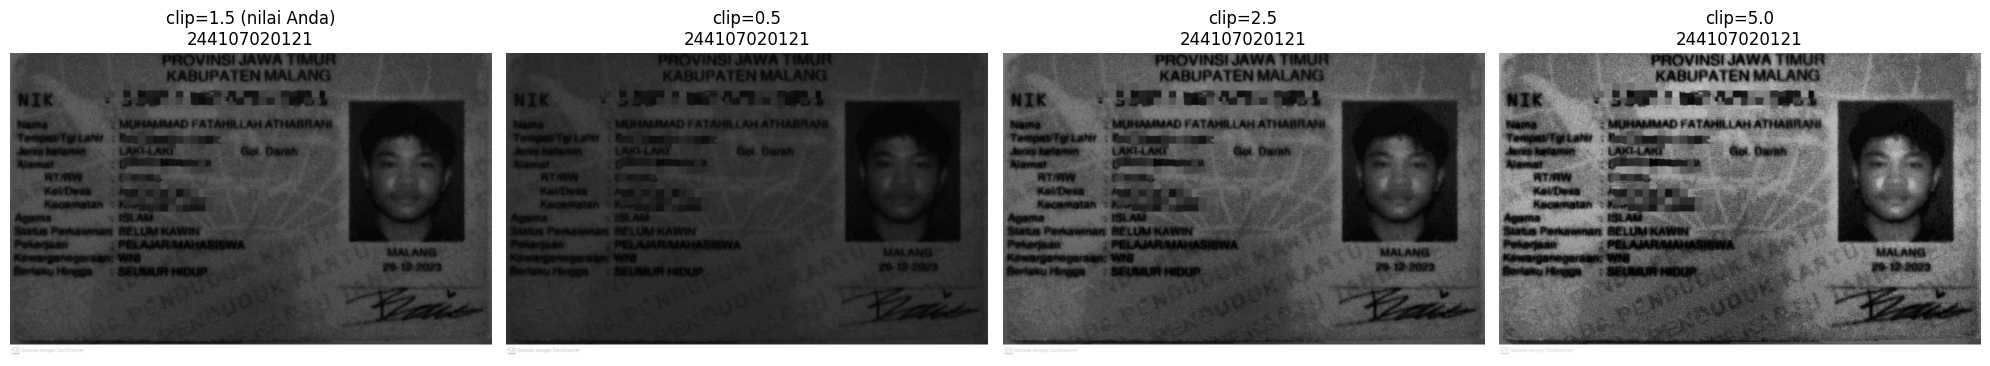

In [14]:
nilai_clip = [0.5, 2.5, 5.0]   # tiga nilai lain di sekitar PARAM['clip']

fig, axs = plt.subplots(1, len(nilai_clip) + 1, figsize=(20, 5))
axs[0].imshow(img_clahe, cmap='gray')
axs[0].set_title(f"clip={PARAM['clip']} (nilai Anda)\n{NIM}")
axs[0].axis('off')

for ax, c in zip(axs[1:], nilai_clip):
    clahe_c = cv.createCLAHE(clipLimit=c, tileGridSize=(PARAM['tile'], PARAM['tile']))
    hasil = clahe_c.apply(img_gelap)
    ax.imshow(hasil, cmap='gray')
    ax.set_title(f'clip={c}\n{NIM}')
    ax.axis('off')

plt.tight_layout()
plt.show()


ClipLimit yang makin besar membuat kontras lokal makin kuat sehingga NIM dan nama pada
kartu makin terbaca, tetapi noise pada area yang relatif rata seperti background KTM juga makin
menonjol. Nilai terbaik ditentukan dari titik saat kontras sudah cukup untuk membaca teks tetapi
noise belum mengganggu, dan bagian citra yang noise-nya mulai terlihat perlu ditunjukkan sebagai
bukti pada laporan.

Perbandingan HE global dan CLAHE dapat diamati dari img_he dan img_clahe pada sel
visualisasi E-2 di atas. CLAHE umumnya membuat area teks dan NIM lebih terbaca karena kontras
diadaptasi per tile atau lokal, sedangkan HE global dapat membuat area terang menjadi over-exposed
atau area gelap tetap kurang kontras jika distribusi intensitas citra tidak merata.

##Percobaan E-3: Dithering (Floyd-Steinberg)

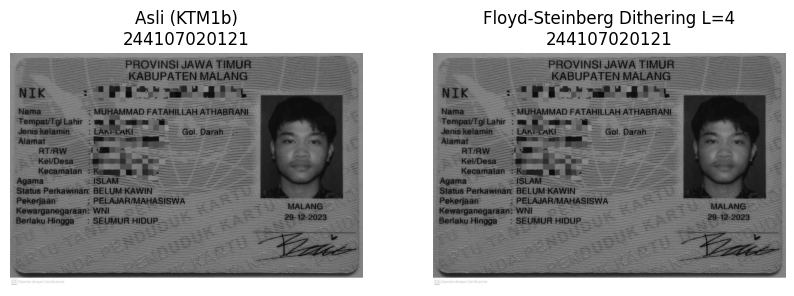

In [15]:
def floyd_steinberg_dithering(image, L):
    # Normalisasi ke 0.0 - 1.0
    img_float = image.astype(float) / 255.0
    h, w = img_float.shape

    # Bikin rasio pembagi kuantisasi
    faktor = L - 1

    for y in range(h):
        for x in range(w):
            old_pixel = img_float[y, x]
            # Pembulatan terdekat sesuai L
            new_pixel = np.round(old_pixel * faktor) / faktor
            img_float[y, x] = new_pixel

            # Hitung error
            quant_error = old_pixel - new_pixel

            # Distribusi error ke tetangga (Floyd-Steinberg mask)
            if x + 1 < w:
                img_float[y, x + 1] += quant_error * 7 / 16
            if x - 1 >= 0 and y + 1 < h:
                img_float[y + 1, x - 1] += quant_error * 3 / 16
            if y + 1 < h:
                img_float[y + 1, x] += quant_error * 5 / 16
            if x + 1 < w and y + 1 < h:
                img_float[y + 1, x + 1] += quant_error * 1 / 16

    return (np.clip(img_float, 0, 1) * 255).astype(np.uint8)

img_dither_target = cv.imread('KTM1b.jpeg', cv.IMREAD_GRAYSCALE)

# Terapkan dithering dengan L=4
hasil_dithering = floyd_steinberg_dithering(img_dither_target.copy(), PARAM['L'])

# Visualisasi
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img_dither_target, cmap='gray')
ax[0].set_title(f'Asli (KTM1b)\n{NIM}')

ax[1].imshow(hasil_dithering, cmap='gray')
ax[1].set_title(f'Floyd-Steinberg Dithering L={PARAM["L"]}\n{NIM}')

for a in ax:
    a.axis('off')
plt.show()

### Langkah 2 — Ekualisasi lalu Dithering vs Dithering Langsung (KTM1a.jpeg)

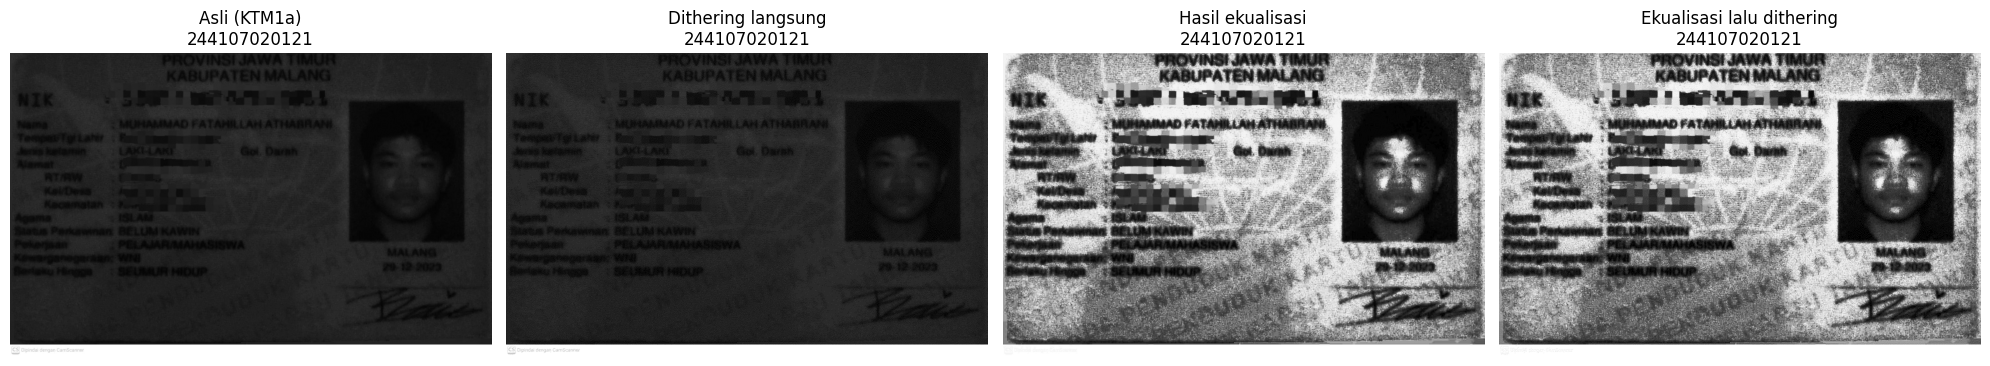

In [16]:
img_ktm1a_gray = cv.imread('KTM1a.jpeg', cv.IMREAD_GRAYSCALE)

# dithering langsung (tanpa ekualisasi)
dither_langsung = floyd_steinberg_dithering(img_ktm1a_gray.copy(), PARAM['L'])

# ekualisasi dulu, baru dithering
img_ktm1a_eq = cv.equalizeHist(img_ktm1a_gray)
dither_eq = floyd_steinberg_dithering(img_ktm1a_eq.copy(), PARAM['L'])

fig, axs = plt.subplots(1, 4, figsize=(20, 5))
axs[0].imshow(img_ktm1a_gray, cmap='gray'); axs[0].set_title(f'Asli (KTM1a)\n{NIM}'); axs[0].axis('off')
axs[1].imshow(dither_langsung, cmap='gray'); axs[1].set_title(f'Dithering langsung\n{NIM}'); axs[1].axis('off')
axs[2].imshow(img_ktm1a_eq, cmap='gray'); axs[2].set_title(f'Hasil ekualisasi\n{NIM}'); axs[2].axis('off')
axs[3].imshow(dither_eq, cmap='gray'); axs[3].set_title(f'Ekualisasi lalu dithering\n{NIM}'); axs[3].axis('off')

for a in axs:
    a.axis('off')
plt.tight_layout()
plt.show()
